In [53]:
#匯入套件與設定環境
!pip install ultralytics
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import requests
from PIL import Image
from PIL import ImageDraw
from google.colab import files
from google.colab import drive
from io import BytesIO
from ultralytics import YOLO
from math import ceil

In [54]:
#掛載Google Drive並建立資料夾
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/WheresWaldo_with_YOLOv8"
folder_list = ["train", "valid", "test"]
folder_list_2 = ["images", "labels"]

for folder in folder_list:
  for folder_2 in folder_list_2:
    folder_path = os.path.join(save_path, folder, folder_2)
    if not os.path.exists(folder_path):
      os.makedirs(folder_path)
      print(f"建立資料夾: {folder_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
#讀取圖片
def get_image_from_url(url_list):

  image_list = []
  image_name_list = []

  for url in url_list:
    response = requests.get(url)
    image = Image.open(BytesIO(response.content))
    image_list.append(image)

    image_name = url.split("/")[-1].split(".")[0]
    image_name_list.append(image_name)

  return image_list, image_name_list

In [65]:
#分割圖片
def generate_image_block(image, labels, block_size, overlap_ratio):

  width, height = image.size
  stride = int(block_size[0] * (1 - overlap_ratio))
  num_row = ceil((height - block_size[1]) / stride) + 1
  num_col = ceil((width - block_size[0]) / stride) + 1

  label_list = []

  for label_str in labels:
    label = label_str.split(" ")

    #還原bounding box在原圖的座標
    label_xy = (float(label[1]) * width, float(label[2]) * height)
    label_wh = (float(label[3]) * width, float(label[4]) * height)
    label_id = label[0]

    label_list.append((label_xy, label_wh, label_id))

  for i in range(num_row):
    block_y1 = i * stride

    #最後一列
    if block_y1 + block_size[1] > height:
      block_y1 = height - block_size[1]

    for j in range(num_col):
      block_x1 = j * stride

      #最後一行
      if block_x1 + block_size[0] > width:
        block_x1 = width - block_size[0]

      block_x2 = block_x1 + block_size[0]
      block_y2 = block_y1 + block_size[1]

      block = image.crop((block_x1, block_y1, block_x2, block_y2))

      label_text = ""

      #調整label
      for label_xy, label_wh, label_id in label_list:

        block_xy = (block_x1, block_y1)
        block_wh = (block_size[0], block_size[1])

        label_final = get_label_in_block(block_xy, block_wh, label_xy, label_wh, label_id, 0.2)
        print(f"區塊 ({i}, {j}) 的標籤: {label_final}")
        if len(label_final) > 0:
          label_text += label_final + "\n"
      #儲存到Google Drive
      file_name = f"{name}_{i:02}_{j:02}"
      image_path = os.path.join(save_path, "train", "images", f"{file_name}.jpg")
      label_path = os.path.join(save_path, "train", "labels", f"{file_name}.txt")

      block.save(image_path)

      with open(label_path, "w") as f:
        f.write(label_text)

In [62]:
#轉換bounding box座標
def get_label_in_block(block_xy, block_wh, label_xy, label_wh, label_id, min_visible_ratio):

  block_x , block_y = block_xy  #區塊在原圖的座標
  block_w , block_h = block_wh  #區塊寬高
  label_x , label_y = label_xy  #bounding box的中心在原圖的座標
  label_w , label_h = label_wh  #bounding box的寬高

  #左上角和右下角
  x1 = label_x - label_w / 2
  y1 = label_y - label_h / 2
  x2 = label_x + label_w / 2
  y2 = label_y + label_h / 2

  #bounding box在區塊內的座標(不超出區塊邊界)
  clipped_x1 = max(x1, block_x)
  clipped_y1 = max(y1, block_y)
  clipped_x2 = min(x2, block_x + block_w)
  clipped_y2 = min(y2, block_y + block_h)

  #bounding box面積和分割後的面積
  area = label_w * label_h
  clipped_w = max(0, clipped_x2 - clipped_x1)
  clipped_h = max(0, clipped_y2 - clipped_y1)
  clipped_area = clipped_w * clipped_h

  #原圖不存在威利，label為空

  #bounding box在區塊邊界上
  if clipped_area == 0:
    return ""

  #比例達到標準，保留bounding box
  visible_ratio = clipped_area / area

  if visible_ratio < min_visible_ratio:
    return ""

  #新bounding box的中心點(平移到原圖的左上角區塊)
  new_label_x = (clipped_x1 + clipped_x2) / 2 - block_x
  new_label_y = (clipped_y1 + clipped_y2) / 2 - block_y

  #縮放到區塊大小，介於0-1
  norm_new_label_x = round(new_label_x / block_w, 6)
  norm_new_label_y = round(new_label_y / block_h, 6)
  norm_clipped_w = round(clipped_w / block_w, 6)
  norm_clipped_h = round(clipped_h / block_h, 6)

  label_str = f"{label_id} {norm_new_label_x} {norm_new_label_y} {norm_clipped_w} {norm_clipped_h}"

  return label_str

In [63]:
#繪製bounding box(正確答案為綠色外框，偵測結果為紅色外框)
def plot_bounding_box(image, label_xy, label_wh, pred_xy = None, pred_wh = None):

  draw = ImageDraw.Draw(image)
  width, height = image.size
  label_x, label_y = label_xy
  label_w, label_h = label_wh

  #還原座標
  label_x = label_x * width
  label_y = label_y * height
  label_w = label_w * width
  label_h = label_h * height

  #左上角和右下角
  x1 = label_x - label_w / 2
  y1 = label_y - label_h / 2
  x2 = label_x + label_w / 2
  y2 = label_y + label_h / 2

  #繪製bounding box
  draw.rectangle([(x1, y1), (x2, y2)], outline="green", width=3)

  if pred_xy is not None and pred_wh is not None:
    pred_x, pred_y = pred_xy
    pred_w, pred_h = pred_wh

    #還原座標
    pred_x = pred_x * width
    pred_y = pred_y * height
    pred_w = pred_w * width
    pred_h = pred_h * height

    #左上角和右下角
    x1 = pred_x - pred_w / 2
    y1 = pred_y - pred_h / 2
    x2 = pred_x + pred_w / 2
    y2 = pred_y + pred_h / 2

    draw.rectangle([(x1, y1), (x2, y2)], outline="red", width=3)

  return image

# #測試函式
# image = plot_bounding_box(bg_rgb, (col, row))
# plt.imshow(image)
# plt.axis("off")
# print(col, row)
# plt.show()

區塊 (0, 0) 的標籤: 
區塊 (0, 0) 的標籤: 0 0.966469 0.742969 0.067062 0.118875
區塊 (0, 0) 的標籤: 
區塊 (0, 1) 的標籤: 
區塊 (0, 1) 的標籤: 0 0.764062 0.742969 0.16225 0.118875
區塊 (0, 1) 的標籤: 
區塊 (0, 2) 的標籤: 
區塊 (0, 2) 的標籤: 0 0.514062 0.742969 0.16225 0.118875
區塊 (0, 2) 的標籤: 
區塊 (0, 3) 的標籤: 
區塊 (0, 3) 的標籤: 0 0.264062 0.742969 0.16225 0.118875
區塊 (0, 3) 的標籤: 
區塊 (0, 4) 的標籤: 
區塊 (0, 4) 的標籤: 0 0.047594 0.742969 0.095187 0.118875
區塊 (0, 4) 的標籤: 
區塊 (0, 5) 的標籤: 
區塊 (0, 5) 的標籤: 0 0.033531 0.742969 0.067062 0.118875
區塊 (0, 5) 的標籤: 
區塊 (1, 0) 的標籤: 0 0.384547 0.928391 0.059031 0.063375
區塊 (1, 0) 的標籤: 0 0.966469 0.492969 0.067062 0.118875
區塊 (1, 0) 的標籤: 
區塊 (1, 1) 的標籤: 0 0.134547 0.928391 0.059031 0.063375
區塊 (1, 1) 的標籤: 0 0.764062 0.492969 0.16225 0.118875
區塊 (1, 1) 的標籤: 
區塊 (1, 2) 的標籤: 
區塊 (1, 2) 的標籤: 0 0.514062 0.492969 0.16225 0.118875
區塊 (1, 2) 的標籤: 
區塊 (1, 3) 的標籤: 
區塊 (1, 3) 的標籤: 0 0.264062 0.492969 0.16225 0.118875
區塊 (1, 3) 的標籤: 
區塊 (1, 4) 的標籤: 
區塊 (1, 4) 的標籤: 0 0.047594 0.492969 0.095187 0.118875
區塊 (1, 4) 的標籤

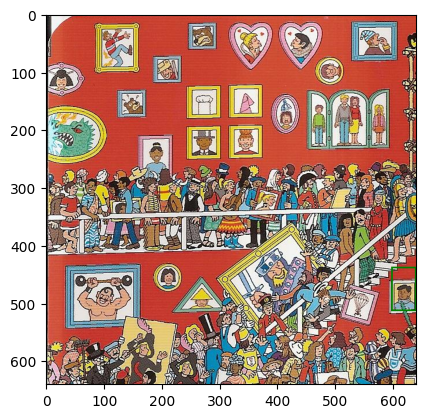

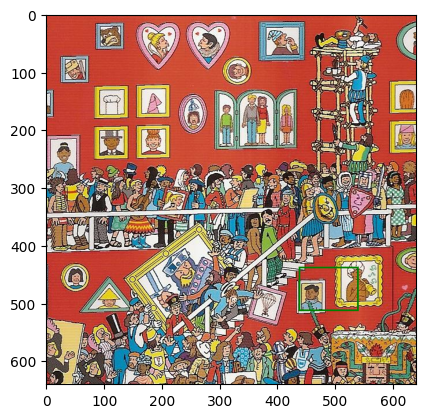

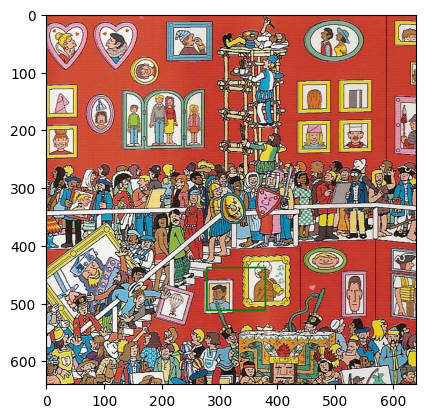

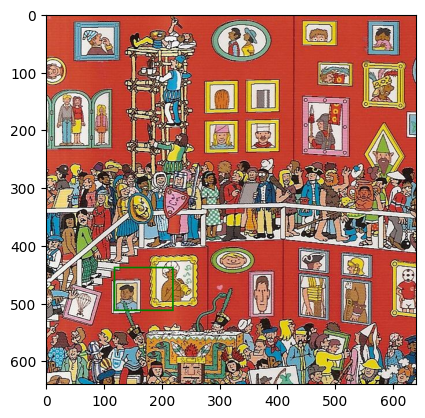

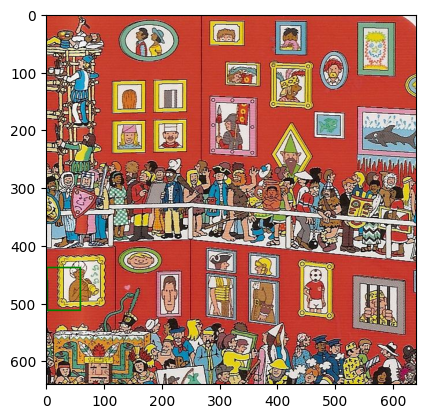

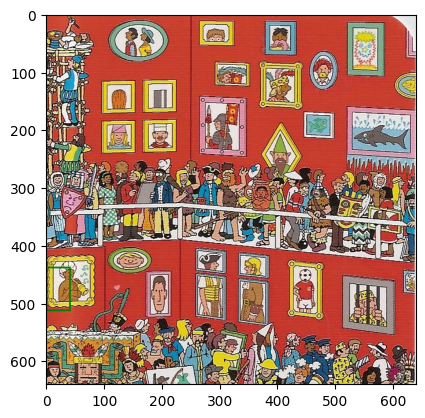

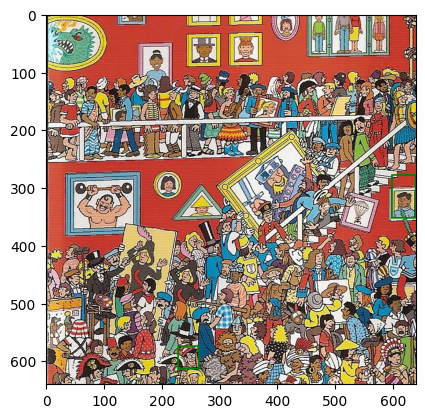

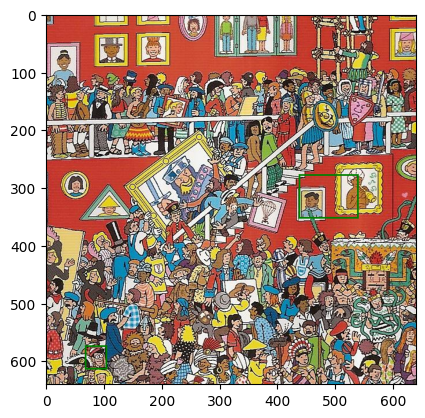

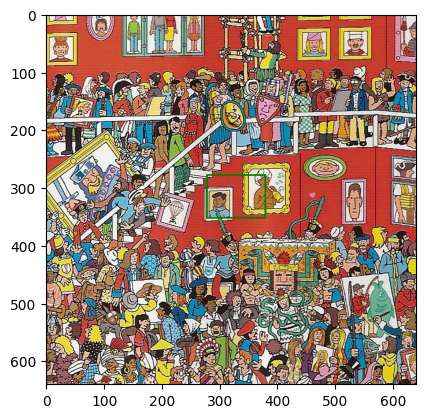

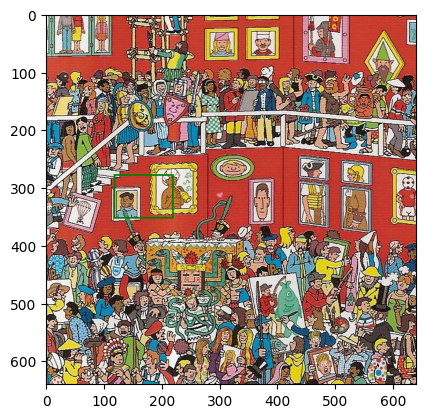

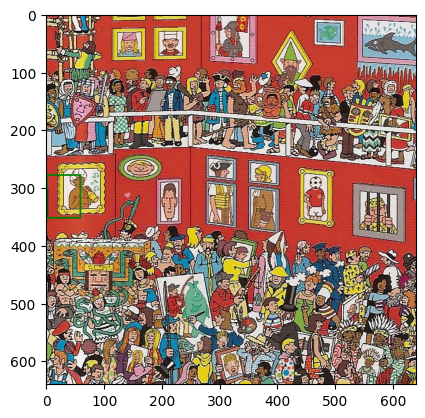

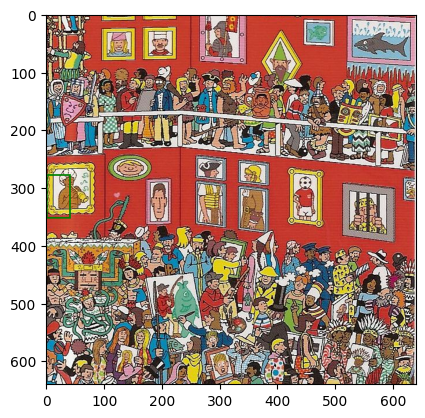

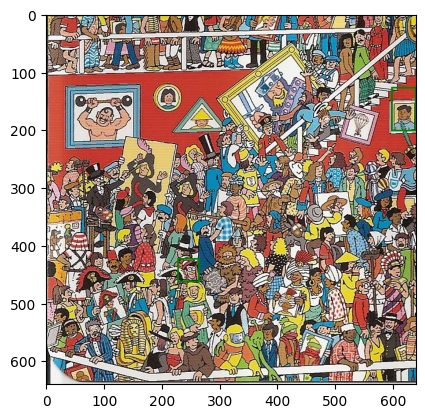

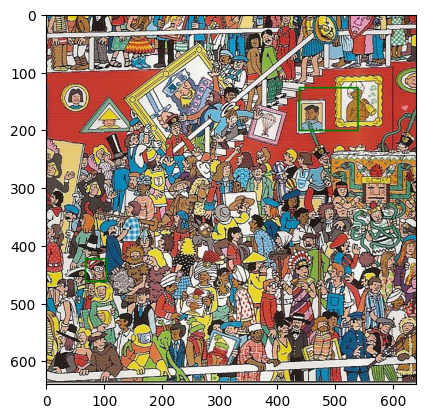

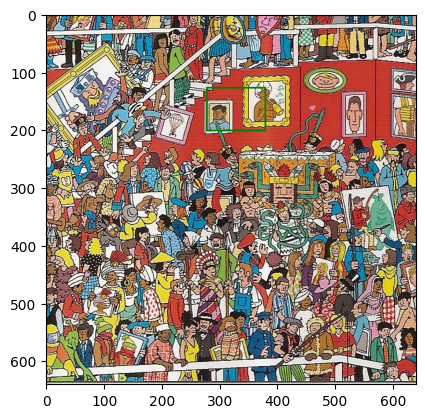

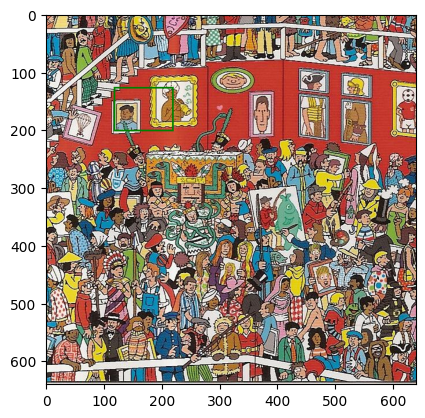

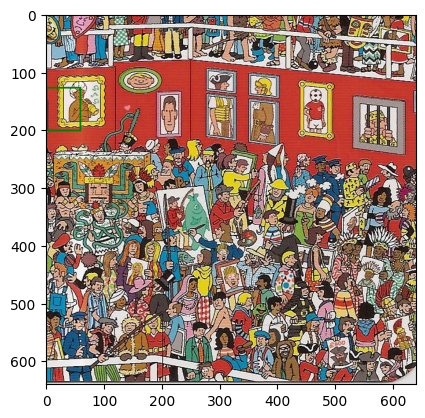

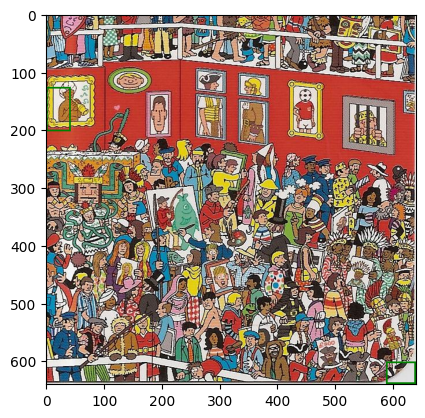

In [66]:
block_size = (640, 640)
overlap_ratio = 0.75

# files.upload()
file_path = "/content/9 (1).txt"

#圖片連結
bg_url_list = {
        # "https://raw.githubusercontent.com/Zong0120/Where_is_Waldo/refs/heads/main/2.jpg",
        # "https://raw.githubusercontent.com/Zong0120/Where_is_Waldo/refs/heads/main/3.jpg",
        # "https://raw.githubusercontent.com/Zong0120/Where_is_Waldo/refs/heads/main/6.jpg",
        # "https://raw.githubusercontent.com/Zong0120/Where_is_Waldo/refs/heads/main/7.jpg",
        "https://raw.githubusercontent.com/Zong0120/Where_is_Waldo/refs/heads/main/9.jpg"
       }

#資料夾連結
train_images_path = "/content/drive/MyDrive/WheresWaldo_with_YOLOv8/train/images"
train_labels_path = "/content/drive/MyDrive/WheresWaldo_with_YOLOv8/train/labels"

#原圖和檔名
bg_list, name_list = get_image_from_url(bg_url_list)

#label list(去掉頭尾的空白和換行字元)
with open(file_path, "r") as f:
    labels = [line.strip() for line in f]


for i in range(len(bg_list)):
  name = name_list[i]
  bg = bg_list[i]
  #原圖分割
  generate_image_block(bg, labels, block_size, overlap_ratio)
  print(f"{name}.jpg 分割完成")

#找出資料夾所有jpg
image_files = [f for f in os.listdir(train_images_path) if any(f.endswith(ext) for ext in [".jpg"])]

for image_file in image_files:
  #打開圖片
  image_path = os.path.join(train_images_path, image_file)
  image = Image.open(image_path)

  text_file = image_file.replace(".jpg", ".txt")
  text_path = os.path.join(train_labels_path, text_file)

  #若有label(txt檔案不是全空)，打開txt
  if os.path.exists(text_path) and os.path.getsize(text_path) > 0:
    with open(text_path, "r") as f:
      labels = [line.strip() for line in f]

  img = image

  #繪製該張圖片(block)上的所有物件框
  for label_str in labels:
    label = label_str.split(" ")
    label_xy = (float(label[1]), float(label[2]))
    label_wh = (float(label[3]), float(label[4]))

    img = plot_bounding_box(img, label_xy, label_wh)

  plt.imshow(img)
  plt.show()